In [1]:
import heapq
import matplotlib.pyplot as plt
from collections import deque

# Grid (0 = free, 1 = obstacle)
grid = [
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,1,0],
    [0,1,0,0,0],
    [0,0,0,0,0]
]

start = (0,0)
goal = (4,4)

In [2]:
# --------------------------
# Manhattan Heuristic
# --------------------------
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

In [3]:
# --------------------------
# Path Reconstruction
# --------------------------
def reconstruct(parent, start, goal):
    path = []
    current = goal
    while current != start:
        path.append(current)
        current = parent[current]
    path.append(start)
    path.reverse()
    return path

In [4]:
# --------------------------
# A* Search (FIXED)
# --------------------------
def a_star(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])

    pq = []
    heapq.heappush(pq, (0, start))

    g_cost = {start: 0}
    parent = {}
    visited = set()
    nodes = 0

    while pq:
        f, current = heapq.heappop(pq)
        nodes += 1

        if current == goal:
            return reconstruct(parent, start, goal), nodes

        if current in visited:
            continue
        visited.add(current)

        x, y = current
        directions = [(-1,0),(1,0),(0,-1),(0,1)]

        for dx, dy in directions:
            nx, ny = x+dx, y+dy
            neighbor = (nx, ny)

            if 0<=nx<rows and 0<=ny<cols and grid[nx][ny]==0:
                new_g = g_cost[current] + 1

                if neighbor not in g_cost or new_g < g_cost[neighbor]:
                    g_cost[neighbor] = new_g
                    f_cost = new_g + manhattan(neighbor, goal)
                    heapq.heappush(pq, (f_cost, neighbor))
                    parent[neighbor] = current

    return None, nodes

In [5]:
# --------------------------
# Run A*
# --------------------------
path, nodes = a_star(grid, start, goal)

print("Path:", path)
print("Path Length:", len(path)-1)
print("Nodes Explored:", nodes)

Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Path Length: 8
Nodes Explored: 20


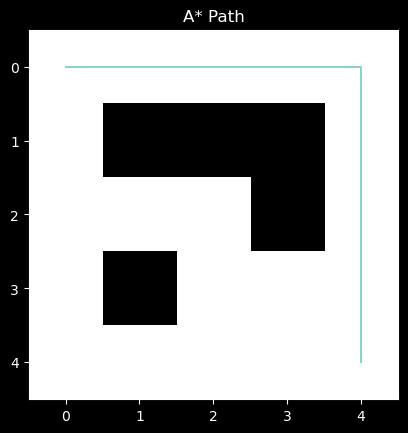

In [6]:
# --------------------------
# Plot
# --------------------------
plt.imshow(grid, cmap='gray_r')

if path:
    x = [p[1] for p in path]
    y = [p[0] for p in path]
    plt.plot(x, y)

plt.title("A* Path")
plt.show()